# XGBoost Model - Hyperparameter & Threshold Tuning

Optimized XGBoost classifier for recession prediction using the 37 selected features.

**Inputs:**
- `data/milestone_ii_preprocessed.pkl` (fully engineered features)
- `data/selected_features.pkl` (37 consensus features from Feature Selection)

**Pipeline:**
1. Data setup (identical to Baseline & Feature Selection)
2. Baseline reproduction with selected features
3. Hyperparameter tuning via Optuna (TPE)
4. Threshold tuning (optimize F1 on validation folds)
5. Final model evaluation with tuned hyperparameters + threshold
6. Per-country analysis & feature importance

**Seeds:** `random_state=42` throughout for reproducibility and apples-to-apples comparison with Baseline.

In [1]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import optuna
from optuna.samplers import TPESampler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    classification_report, roc_auc_score, precision_recall_curve, auc,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, confusion_matrix, ConfusionMatrixDisplay
)
from model_utils import (
    compute_fold_metrics, compute_country_metrics,
    plot_roc_pr_curves, plot_confusion_matrices, plot_optuna_study,
    sweep_thresholds, plot_threshold_curves,
    build_model_comparison, export_model_config,
)

optuna.logging.set_verbosity(optuna.logging.WARNING)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

RANDOM_STATE = 42
N_SPLITS = 5
MAX_ROUNDS = 1000
EARLY_STOP = 30
VAL_FRAC = 0.2  # fraction of training data held out for early stopping
N_OPTUNA_TRIALS = 250

### Load Data and Selected Features

Load the fully-engineered preprocessed dataset and the consensus feature set
identified during feature selection (37 features from the incomplete-data pipeline).

In [2]:
# ── Load Data ─────────────────────────────────────────────────────────────────
df = pd.read_pickle('../data/milestone_ii_preprocessed.pkl')

with open('../data/selected_features.pkl', 'rb') as f:
    selected_features = pickle.load(f)

print(f'Dataset shape: {df.shape}')
print(f'Selected features: {len(selected_features)}')
print(f'Date range: {df.index.get_level_values("date").min()} to {df.index.get_level_values("date").max()}')
print(f'Countries: {df.index.get_level_values("country").unique().tolist()}')

Dataset shape: (5508, 237)
Selected features: 37
Date range: 1970-01-01 00:00:00 to 2020-12-01 00:00:00
Countries: ['Australia', 'Canada', 'France', 'Germany', 'Italy', 'Japan', 'South Korea', 'UK', 'USA']


### Data Preparation

Apply the same preprocessing used in Baseline and Feature Selection:
- Exclude post-2019 data (COVID contamination of pre-recession labels)
- Replace infinities with NaN (XGBoost handles NaN natively)
- Compute class imbalance weight for the positive class

In [3]:
# ── Data Preparation (identical to Baseline & Feature Selection) ────────────
df_flat = df.reset_index()
df_flat = df_flat[df_flat['date'] < '2019-01-01']  # Exclude pre-COVID contamination

X = df_flat[selected_features].copy()
y = df_flat['pre_recession']

# Replace inf/-inf with NaN (XGBoost handles NaN natively)
inf_count = np.isinf(X).sum().sum()
X = X.replace([np.inf, -np.inf], np.nan)

scale_pos_weight_global = (y == 0).sum() / (y == 1).sum()

print(f'Observations: {len(X)}')
print(f'Features: {len(selected_features)}')
print(f'Replaced {inf_count} infinite values with NaN')
print(f'Positive class: {y.sum()} ({y.mean():.1%})')
print(f'Global scale_pos_weight: {scale_pos_weight_global:.2f}')

Observations: 5292
Features: 37
Replaced 0 infinite values with NaN
Positive class: 1111 (21.0%)
Global scale_pos_weight: 3.76


### Pipeline Helper Functions

Reusable functions shared by both the original (with-NaN) and complete (NaN-free)
data sections. Defining them once avoids code duplication across the two pipelines.

#### `run_baseline_cv` — Baseline XGBoost with Default Hyperparameters

Runs XGBoost with default hyperparameters (`n_estimators=100`, `max_depth=6`,
`learning_rate=0.1`) across time-series CV folds. Establishes the starting point
that hyperparameter tuning must beat.

In [4]:
def run_baseline_cv(X, y, df_flat):
    """Run baseline XGBoost (default HP) across time-series CV folds."""
    tscv = TimeSeriesSplit(n_splits=N_SPLITS)
    results, preds = [], []

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        test_countries = df_flat.iloc[test_idx]['country'].values

        spw = (y_train == 0).sum() / (y_train == 1).sum()

        model = xgb.XGBClassifier(
            n_estimators=100, max_depth=6, learning_rate=0.1,
            scale_pos_weight=spw, random_state=RANDOM_STATE,
            n_jobs=-1, verbosity=0
        )
        model.fit(X_train, y_train)

        y_proba = model.predict_proba(X_test)[:, 1]
        y_pred = model.predict(X_test)

        roc = roc_auc_score(y_test, y_proba)
        prec_arr, rec_arr, _ = precision_recall_curve(y_test, y_proba)
        pr = auc(rec_arr, prec_arr)
        f1 = f1_score(y_test, y_pred)

        results.append({'fold': fold + 1, 'roc_auc': roc, 'pr_auc': pr, 'f1': f1})
        preds.append(pd.DataFrame({
            'country': test_countries, 'y_true': y_test.values,
            'y_pred': y_pred, 'y_proba': y_proba, 'fold': fold + 1
        }))

        train_dates = df_flat.iloc[train_idx]['date']
        test_dates = df_flat.iloc[test_idx]['date']
        print(f'Fold {fold+1}: Train to {train_dates.max().strftime("%Y-%m")}, '
              f'Test {test_dates.min().strftime("%Y-%m")}-{test_dates.max().strftime("%Y-%m")} | '
              f'ROC-AUC: {roc:.3f} | PR-AUC: {pr:.3f} | F1: {f1:.3f}')

    results_df = pd.DataFrame(results)
    pred_df = pd.concat(preds, ignore_index=True)

    print(f'\nBaseline ({len(X.columns)} selected features, default hyperparameters):')
    print(f'  Mean ROC-AUC: {results_df["roc_auc"].mean():.3f} ± {results_df["roc_auc"].std():.3f}')
    print(f'  Mean PR-AUC:  {results_df["pr_auc"].mean():.3f} ± {results_df["pr_auc"].std():.3f}')
    print(f'  Mean F1:      {results_df["f1"].mean():.3f} ± {results_df["f1"].std():.3f}')

    return results_df, pred_df



#### `run_optuna_tuning` — Bayesian Hyperparameter Search

Uses Optuna's Tree-structured Parzen Estimators (TPE) to search 12 hyperparameters.
Each trial runs full 5-fold CV with early stopping; `MedianPruner` kills unpromising
trials early. Optimizes mean PR-AUC across folds.

In [5]:
def run_optuna_tuning(X, y, study_name='xgboost_recession'):
    """Run Optuna TPE hyperparameter search, maximizing mean CV PR-AUC."""
    tscv = TimeSeriesSplit(n_splits=N_SPLITS)
    folds = list(tscv.split(X))

    def objective(trial):
        # Tree growth strategy
        grow_policy = trial.suggest_categorical('grow_policy', ['depthwise', 'lossguide'])

        params = {
            'tree_method': 'hist',
            'grow_policy': grow_policy,
            'max_depth': trial.suggest_int('max_depth', 2, 15),
            'max_bin': trial.suggest_int('max_bin', 64, 512),
            'learning_rate': trial.suggest_float('learning_rate', 0.003, 0.50, log=True),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.2, 1.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
            'gamma': trial.suggest_float('gamma', 0.0, 5.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
            'max_delta_step': trial.suggest_int('max_delta_step', 0, 10),
        }

        # max_leaves only matters for lossguide growth
        if grow_policy == 'lossguide':
            params['max_leaves'] = trial.suggest_int('max_leaves', 4, 64)

        fold_pr, fold_roc, fold_iters = [], [], []
        for fold_idx, (train_idx, test_idx) in enumerate(folds):
            X_train_full, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train_full, y_test = y.iloc[train_idx], y.iloc[test_idx]

            val_size = int(len(X_train_full) * VAL_FRAC)
            X_train = X_train_full.iloc[:-val_size]
            y_train = y_train_full.iloc[:-val_size]
            X_val = X_train_full.iloc[-val_size:]
            y_val = y_train_full.iloc[-val_size:]

            spw = (y_train == 0).sum() / (y_train == 1).sum()

            model = xgb.XGBClassifier(
                n_estimators=MAX_ROUNDS,
                **params,
                scale_pos_weight=spw,
                random_state=RANDOM_STATE,
                n_jobs=-1,
                verbosity=0,
                eval_metric='aucpr',
                early_stopping_rounds=EARLY_STOP,
            )
            model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

            y_proba = model.predict_proba(X_test)[:, 1]
            fold_roc.append(roc_auc_score(y_test, y_proba))
            prec, rec, _ = precision_recall_curve(y_test, y_proba)
            fold_pr.append(auc(rec, prec))
            fold_iters.append(model.best_iteration)

            # Report running mean to Optuna pruner
            trial.report(float(np.mean(fold_pr)), fold_idx)
            if trial.should_prune():
                raise optuna.TrialPruned()

        trial.set_user_attr('mean_roc_auc', float(np.mean(fold_roc)))
        trial.set_user_attr('std_pr_auc', float(np.std(fold_pr)))
        trial.set_user_attr('mean_n_estimators', int(np.mean(fold_iters)))

        return float(np.mean(fold_pr))

    print(f'Optuna: Running {N_OPTUNA_TRIALS} trials with TPE sampler...')

    study = optuna.create_study(
        direction='maximize',
        sampler=TPESampler(seed=RANDOM_STATE),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=20, n_warmup_steps=1),
        study_name=study_name,
    )
    study.optimize(objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=True)

    best_params = {
        **study.best_params,
        'tree_method': 'hist',
    }

    n_pruned = len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])

    print(f'\nOptuna search complete ({len(study.trials)} trials, {n_pruned} pruned)')
    print(f'Best PR-AUC: {study.best_value:.4f} ± {study.best_trial.user_attrs["std_pr_auc"]:.4f}')
    print(f'Best ROC-AUC: {study.best_trial.user_attrs["mean_roc_auc"]:.4f}')
    print(f'Mean n_estimators (from early stopping): {study.best_trial.user_attrs["mean_n_estimators"]}')
    print(f'\nBest hyperparameters:')
    for param, val in sorted(best_params.items()):
        print(f'  {param}: {val:.4f}' if isinstance(val, float) else f'  {param}: {val}')

    return best_params, study



#### `evaluate_tuned_model` — Re-Evaluate with Best Hyperparameters

Re-runs 5-fold time-series CV using the best hyperparameters from Optuna.
Collects both validation predictions (for threshold tuning) and test predictions
(for final unbiased evaluation).

In [6]:
def evaluate_tuned_model(X, y, df_flat, best_params):
    """Evaluate tuned HP across CV folds with early stopping, collecting val + test predictions."""
    tscv = TimeSeriesSplit(n_splits=N_SPLITS)
    tuned_results, tuned_preds, val_preds = [], [], []

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
        X_train_full, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train_full, y_test = y.iloc[train_idx], y.iloc[test_idx]
        test_countries = df_flat.iloc[test_idx]['country'].values

        val_size = int(len(X_train_full) * VAL_FRAC)
        X_train = X_train_full.iloc[:-val_size]
        y_train = y_train_full.iloc[:-val_size]
        X_val = X_train_full.iloc[-val_size:]
        y_val = y_train_full.iloc[-val_size:]

        spw = (y_train == 0).sum() / (y_train == 1).sum()

        model = xgb.XGBClassifier(
            **best_params,
            n_estimators=MAX_ROUNDS,
            scale_pos_weight=spw,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=0,
            eval_metric='aucpr',
            early_stopping_rounds=EARLY_STOP,
        )
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

        # Validation predictions for threshold tuning
        val_proba = model.predict_proba(X_val)[:, 1]
        val_preds.append(pd.DataFrame({
            'y_true': y_val.values, 'y_proba': val_proba, 'fold': fold + 1
        }))

        # Test predictions for final evaluation
        y_proba = model.predict_proba(X_test)[:, 1]
        y_pred = model.predict(X_test)

        roc = roc_auc_score(y_test, y_proba)
        prec_arr, rec_arr, _ = precision_recall_curve(y_test, y_proba)
        pr = auc(rec_arr, prec_arr)
        f1 = f1_score(y_test, y_pred)

        tuned_results.append({'fold': fold + 1, 'roc_auc': roc, 'pr_auc': pr, 'f1': f1})
        tuned_preds.append(pd.DataFrame({
            'country': test_countries, 'y_true': y_test.values,
            'y_pred': y_pred, 'y_proba': y_proba, 'fold': fold + 1
        }))

        train_dates = df_flat.iloc[train_idx]['date']
        test_dates = df_flat.iloc[test_idx]['date']
        print(f'Fold {fold+1}: Train to {train_dates.max().strftime("%Y-%m")}, '
              f'Test {test_dates.min().strftime("%Y-%m")}-{test_dates.max().strftime("%Y-%m")} | '
              f'ROC-AUC: {roc:.3f} | PR-AUC: {pr:.3f} | F1: {f1:.3f}')

    tuned_df = pd.DataFrame(tuned_results)
    tuned_pred_df = pd.concat(tuned_preds, ignore_index=True)
    val_pred_df = pd.concat(val_preds, ignore_index=True)

    print(f'\nTuned hyperparameters (default threshold=0.5):')
    print(f'  Mean ROC-AUC: {tuned_df["roc_auc"].mean():.3f} ± {tuned_df["roc_auc"].std():.3f}')
    print(f'  Mean PR-AUC:  {tuned_df["pr_auc"].mean():.3f} ± {tuned_df["pr_auc"].std():.3f}')
    print(f'  Mean F1:      {tuned_df["f1"].mean():.3f} ± {tuned_df["f1"].std():.3f}')

    return tuned_df, tuned_pred_df, val_pred_df



#### `tune_threshold` — Optimize Decision Threshold

Sweeps thresholds 0.05–0.95 on validation-fold predictions to find the threshold
maximizing mean F1 score. Applies the selected threshold to test predictions and
reports naive baselines (predict-all-positive, predict-all-negative, random).

In [7]:
def tune_threshold(val_pred_df, tuned_pred_df, plot=True):
    """Sweep thresholds on validation data, apply best to test predictions.

    Modifies tuned_pred_df in-place (adds 'y_pred_opt' column).
    Returns (best_threshold, naive_all_pos_f1, mean_prevalence).
    """
    # Sweep validation metrics — threshold is selected here
    (thresholds, mean_val_f1, mean_val_prec, mean_val_rec,
     _, _) = sweep_thresholds(val_pred_df, N_SPLITS)
    best_threshold_idx = np.argmax(mean_val_f1)
    best_threshold = thresholds[best_threshold_idx]

    print(f'Optimal threshold (from validation data): {best_threshold:.2f}')
    print(f'  Mean validation F1 at optimal threshold: {mean_val_f1[best_threshold_idx]:.3f}')

    # Sweep test metrics — for visualization / reporting only
    (_, mean_test_f1, mean_test_prec, mean_test_rec,
     naive_all_pos_f1, mean_prevalence) = sweep_thresholds(tuned_pred_df, N_SPLITS)

    # Apply optimal threshold to test predictions
    tuned_pred_df['y_pred_opt'] = (tuned_pred_df['y_proba'] >= best_threshold).astype(int)

    print(f'\n  Test F1 at optimal threshold:        {mean_test_f1[best_threshold_idx]:.3f}')
    print(f'  Test Precision at optimal threshold:  {mean_test_prec[best_threshold_idx]:.3f}')
    print(f'  Test Recall at optimal threshold:     {mean_test_rec[best_threshold_idx]:.3f}')
    print(f'  Test F1 at default threshold (0.50):  {mean_test_f1[np.argmin(np.abs(thresholds - 0.5))]:.3f}')
    print(f'\nNaive baselines (must beat these):')
    print(f'  Predict-all-positive F1: {naive_all_pos_f1:.3f}')
    print(f'  Predict-all-negative F1: 0.000')
    print(f'  Random classifier ROC-AUC: 0.500')
    print(f'  Random classifier PR-AUC:  {mean_prevalence:.3f} (= class prevalence)')

    if plot:
        fig, (ax_val, ax_test) = plt.subplots(1, 2, figsize=(16, 6))

        # Left: Validation metrics (threshold selected here)
        plot_threshold_curves(thresholds, mean_val_f1, mean_val_prec, mean_val_rec,
                              best_threshold, naive_all_pos_f1,
                              ax=ax_val, title='Validation Metrics (threshold selected here)')

        # Right: Test metrics (generalization)
        plot_threshold_curves(thresholds, mean_test_f1, mean_test_prec, mean_test_rec,
                              best_threshold, naive_all_pos_f1,
                              ax=ax_test, title='Test Metrics (generalization)')

        plt.suptitle('Threshold Tuning', fontsize=13)
        plt.tight_layout()
        plt.show()

    return best_threshold, naive_all_pos_f1, mean_prevalence

#### Shared Evaluation Utilities

The following functions are imported from `model_utils.py` (shared across all
supervised model notebooks):

- `compute_fold_metrics` — Per-fold accuracy, precision, recall, F1, ROC-AUC, PR-AUC
- `compute_country_metrics` — Per-country metrics aggregated across folds
- `plot_roc_pr_curves`, `plot_confusion_matrices` — Diagnostic visualizations
- `plot_optuna_study` — Optuna optimization history and HP importance
- `sweep_thresholds`, `plot_threshold_curves` — Threshold sweep computation and plotting
- `build_model_comparison` — Baseline vs tuned comparison table
- `export_model_config` — Save model configuration pickle

In [8]:
print('Pipeline helper functions defined.')
print('Shared evaluation utilities imported from model_utils.py.')

Pipeline helper functions defined.
Shared evaluation utilities imported from model_utils.py.


## 1. Baseline Reproduction with Selected Features

Reproduce the baseline XGBoost configuration (identical hyperparameters) using only
the 36 selected features. This establishes the starting point for optimization.

In [9]:
baseline_df, baseline_pred_df = run_baseline_cv(X, y, df_flat)

Fold 1: Train to 1978-02, Test 1978-03-1986-04 | ROC-AUC: 0.651 | PR-AUC: 0.415 | F1: 0.123
Fold 2: Train to 1986-04, Test 1986-05-1994-06 | ROC-AUC: 0.715 | PR-AUC: 0.322 | F1: 0.330
Fold 3: Train to 1994-06, Test 1994-07-2002-08 | ROC-AUC: 0.681 | PR-AUC: 0.420 | F1: 0.423
Fold 4: Train to 2002-08, Test 2002-09-2010-10 | ROC-AUC: 0.805 | PR-AUC: 0.547 | F1: 0.505
Fold 5: Train to 2010-10, Test 2010-11-2018-12 | ROC-AUC: 0.641 | PR-AUC: 0.324 | F1: 0.347

Baseline (37 selected features, default hyperparameters):
  Mean ROC-AUC: 0.699 ± 0.066
  Mean PR-AUC:  0.405 ± 0.092
  Mean F1:      0.346 ± 0.143


## 2. Hyperparameter Tuning (Optuna TPE)

**Optuna** uses Tree-structured Parzen Estimators (TPE) — a Bayesian approach that
models the search space and concentrates sampling around promising regions.

- **250 trials** with per-fold `scale_pos_weight` and early stopping
- **12 hyperparameters** tuned:
  - Tree structure: `max_depth`, `max_bin`, `min_child_weight`, `gamma`, `max_delta_step`
  - Tree growth: `grow_policy` (`depthwise` vs `lossguide`), `max_leaves` (conditional on `lossguide`)
  - Sampling: `subsample`, `colsample_bytree`
  - Regularization: `learning_rate`, `reg_alpha`, `reg_lambda`
- Log-uniform sampling for `learning_rate`, `reg_alpha`, `reg_lambda`
  (spans orders of magnitude)
- `max_bin` controls histogram resolution for the `hist` tree method — fewer bins
  add regularization and speed up training
- `max_delta_step` helps with imbalanced classification by limiting step size
- `lossguide` growth (leaf-wise, like LightGBM) expands the leaf with the
  highest loss reduction — can find better splits but risks overfitting
- **Scoring:** PR-AUC (more informative than ROC-AUC for imbalanced recession
  forecasting)
- **Pruning:** `MedianPruner` kills unpromising trials early by comparing
  intermediate per-fold results against completed trials

In [10]:
optuna_best_params, study = run_optuna_tuning(X, y)

Optuna: Running 250 trials with TPE sampler...


  0%|          | 0/250 [00:00<?, ?it/s]


Optuna search complete (250 trials, 77 pruned)
Best PR-AUC: 0.4783 ± 0.0965
Best ROC-AUC: 0.7310
Mean n_estimators (from early stopping): 25

Best hyperparameters:
  colsample_bytree: 0.9060
  gamma: 1.8239
  grow_policy: depthwise
  learning_rate: 0.0047
  max_bin: 463
  max_delta_step: 3
  max_depth: 2
  min_child_weight: 1
  reg_alpha: 0.6526
  reg_lambda: 0.1197
  subsample: 0.8257
  tree_method: hist


### Optuna Results Visualization

Two diagnostic plots:
- **Optimization history**: Each trial's PR-AUC with the running best, showing
  how TPE concentrates sampling around promising regions over time.
- **Hyperparameter importance**: fANOVA-style variance decomposition showing which
  hyperparameters have the most impact on model performance.

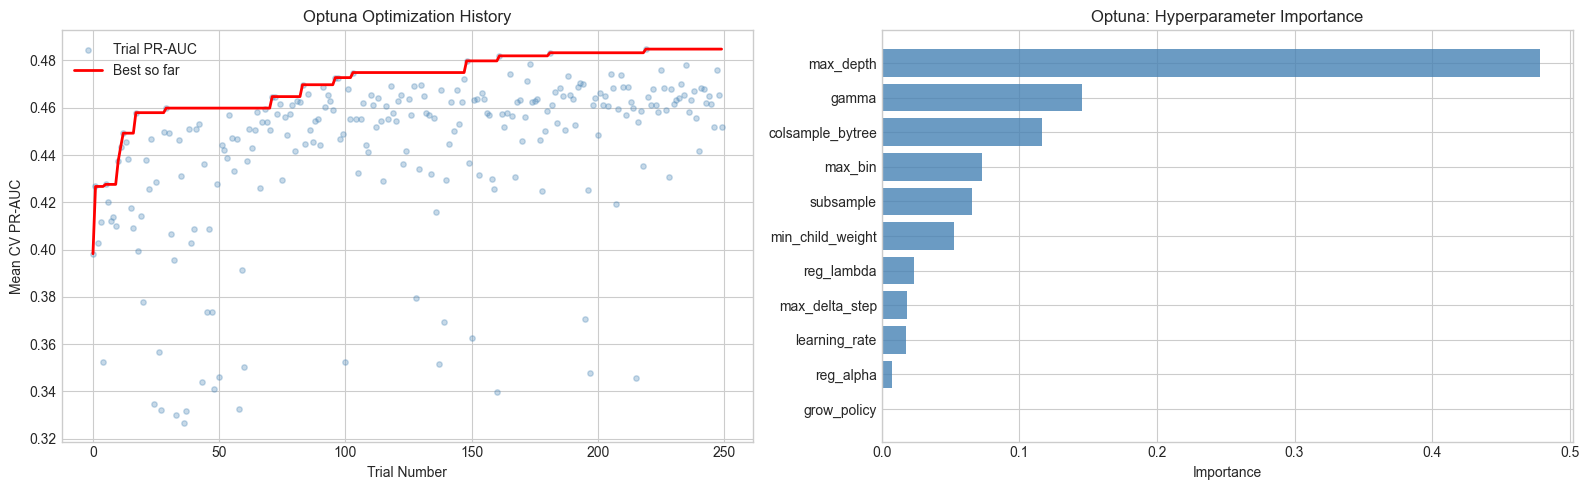

In [11]:
plot_optuna_study(study)

### Best Hyperparameters

Lock in the best hyperparameters from Optuna for downstream evaluation.

In [12]:
# ── Set best_params for downstream evaluation ───────────────────────────────
best_params = optuna_best_params

print(f'Best PR-AUC: {study.best_value:.4f} ± {study.best_trial.user_attrs["std_pr_auc"]:.4f}')
print(f'Best ROC-AUC: {study.best_trial.user_attrs["mean_roc_auc"]:.4f}')
print(f'\nUsing Optuna best hyperparameters for downstream evaluation:')
for param, val in sorted(best_params.items()):
    print(f'  {param}: {val:.4f}' if isinstance(val, float) else f'  {param}: {val}')

Best PR-AUC: 0.4783 ± 0.0965
Best ROC-AUC: 0.7310

Using Optuna best hyperparameters for downstream evaluation:
  colsample_bytree: 0.9060
  gamma: 1.8239
  grow_policy: depthwise
  learning_rate: 0.0047
  max_bin: 463
  max_delta_step: 3
  max_depth: 2
  min_child_weight: 1
  reg_alpha: 0.6526
  reg_lambda: 0.1197
  subsample: 0.8257
  tree_method: hist


## 3. Evaluate Tuned Hyperparameters with Per-Fold Metrics

Re-run 5-fold time-series CV with the best hyperparameters (including
`n_estimators` determined by early stopping). `scale_pos_weight` is recomputed
per fold (consistent with baseline).

In [13]:
tuned_df, tuned_pred_df, val_pred_df = evaluate_tuned_model(X, y, df_flat, best_params)

Fold 1: Train to 1978-02, Test 1978-03-1986-04 | ROC-AUC: 0.723 | PR-AUC: 0.546 | F1: 0.361
Fold 2: Train to 1986-04, Test 1986-05-1994-06 | ROC-AUC: 0.717 | PR-AUC: 0.381 | F1: 0.394
Fold 3: Train to 1994-06, Test 1994-07-2002-08 | ROC-AUC: 0.728 | PR-AUC: 0.556 | F1: 0.540
Fold 4: Train to 2002-08, Test 2002-09-2010-10 | ROC-AUC: 0.823 | PR-AUC: 0.568 | F1: 0.461
Fold 5: Train to 2010-10, Test 2010-11-2018-12 | ROC-AUC: 0.664 | PR-AUC: 0.342 | F1: 0.383

Tuned hyperparameters (default threshold=0.5):
  Mean ROC-AUC: 0.731 ± 0.057
  Mean PR-AUC:  0.478 ± 0.108
  Mean F1:      0.428 ± 0.073


## 4. Threshold Tuning

The default XGBoost threshold (0.5) is not necessarily optimal for imbalanced data.
We sweep thresholds using each validation fold's predictions to find the threshold
that maximizes F1 score across all folds, then evaluate the impact.

**Naive baselines we must beat** (to demonstrate the model has learned something useful):
- **Predict-all-positive**: Precision = prevalence, Recall = 1.0, F1 = 2 * prevalence / (1 + prevalence)
- **Predict-all-negative**: F1 = 0 (no true positives)
- **Random classifier**: ROC-AUC = 0.5, PR-AUC ≈ prevalence

Optimal threshold (from validation data): 0.50
  Mean validation F1 at optimal threshold: 0.396

  Test F1 at optimal threshold:        0.428
  Test Precision at optimal threshold:  0.382
  Test Recall at optimal threshold:     0.655
  Test F1 at default threshold (0.50):  0.428

Naive baselines (must beat these):
  Predict-all-positive F1: 0.346
  Predict-all-negative F1: 0.000
  Random classifier ROC-AUC: 0.500
  Random classifier PR-AUC:  0.211 (= class prevalence)


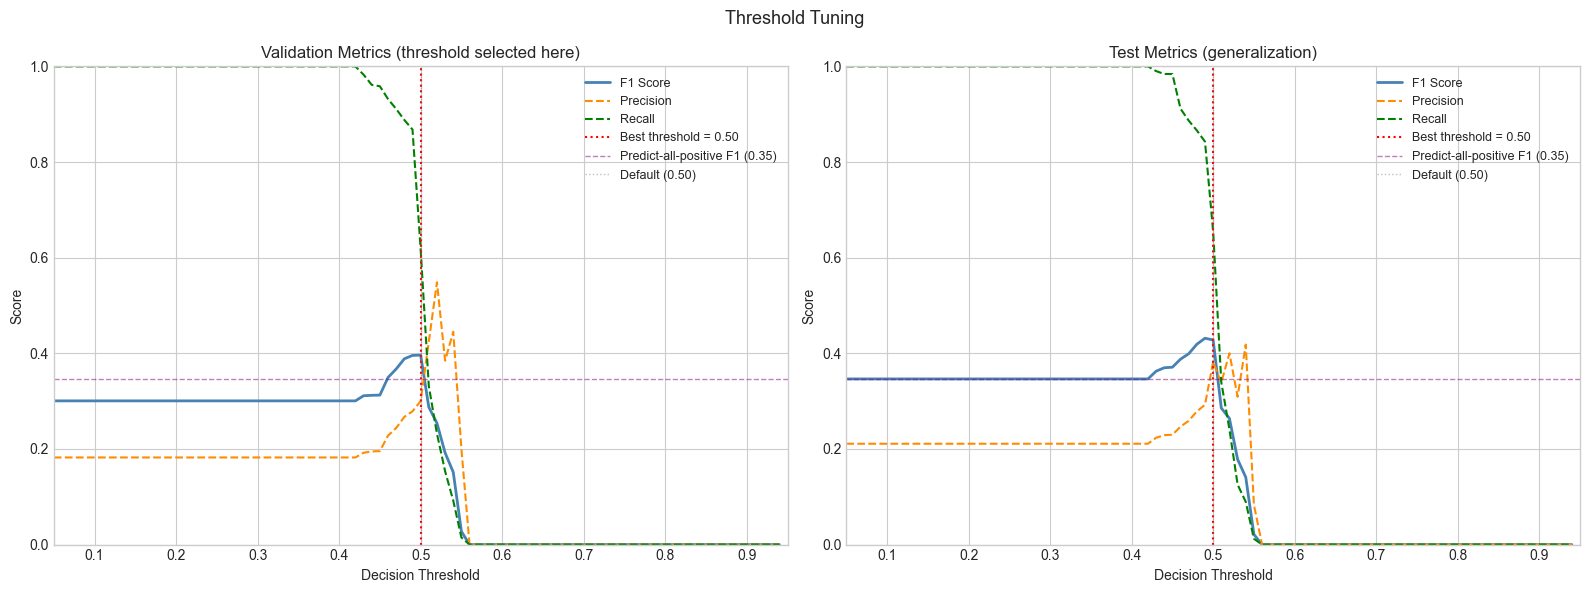

In [14]:
best_threshold, naive_all_pos_f1, mean_prevalence = tune_threshold(val_pred_df, tuned_pred_df, plot=True)

### Per-Fold Threshold Impact

Compare each fold's F1 at the optimal threshold vs the default 0.5 threshold
to quantify how much threshold tuning helps (or if 0.5 was already optimal).

In [15]:
# Per-fold F1 at optimal threshold
print(f'Per-fold F1 at optimal threshold ({best_threshold:.2f}):')
for fold_idx in range(N_SPLITS):
    fold_data = tuned_pred_df[tuned_pred_df['fold'] == fold_idx + 1]
    y_pred_opt = (fold_data['y_proba'] >= best_threshold).astype(int)
    f1_opt = f1_score(fold_data['y_true'], y_pred_opt, zero_division=0)
    f1_def = f1_score(fold_data['y_true'], fold_data['y_pred'], zero_division=0)
    print(f'  Fold {fold_idx+1}: F1={f1_opt:.3f} (vs default: {f1_def:.3f}, '
          f'delta: {f1_opt - f1_def:+.3f})')

Per-fold F1 at optimal threshold (0.50):
  Fold 1: F1=0.361 (vs default: 0.361, delta: +0.000)
  Fold 2: F1=0.394 (vs default: 0.394, delta: +0.000)
  Fold 3: F1=0.540 (vs default: 0.540, delta: +0.000)
  Fold 4: F1=0.461 (vs default: 0.461, delta: +0.000)
  Fold 5: F1=0.383 (vs default: 0.383, delta: +0.000)


## 5. Final Model Evaluation

Combine the tuned hyperparameters with the optimal threshold. Run full CV
evaluation to produce the final performance metrics for comparison with the baseline.

In [16]:
final_df = compute_fold_metrics(tuned_pred_df, N_SPLITS, best_threshold)

Per-Fold Metrics (tuned HP + optimal threshold)
 fold  accuracy  precision  recall    f1  roc_auc  pr_auc
    1     0.783      0.628   0.254 0.361    0.723   0.546
    2     0.488      0.253   0.896 0.394    0.717   0.381
    3     0.645      0.421   0.754 0.540    0.728   0.556
    4     0.689      0.328   0.775 0.461    0.823   0.568
    5     0.656      0.282   0.595 0.383    0.664   0.342

Mean ± Std:
  accuracy    : 0.652 ± 0.107
  precision   : 0.382 ± 0.151
  recall      : 0.655 ± 0.249
  f1          : 0.428 ± 0.073
  roc_auc     : 0.731 ± 0.057
  pr_auc      : 0.478 ± 0.108


### Per-Country Classification Metrics

Aggregate predictions across all CV folds for each country to assess geographic
performance variation.

In [17]:
country_df = compute_country_metrics(tuned_pred_df)

Per-Country Classification Metrics (Tuned Model, Aggregated Across All CV Folds)
             Accuracy  Precision  Recall    F1  ROC-AUC  PR-AUC  Support (pos)  Total
Country                                                                              
Australia       0.708      0.390   0.550 0.456    0.716   0.474            109    490
Canada          0.637      0.310   0.482 0.378    0.646   0.291            112    490
France          0.704      0.352   0.703 0.469    0.828   0.561             91    490
Germany         0.690      0.391   0.731 0.510    0.769   0.485            108    490
Italy           0.676      0.350   0.868 0.498    0.811   0.507             91    490
Japan           0.592      0.302   0.565 0.394    0.643   0.284            115    490
South Korea     0.584      0.290   0.455 0.354    0.563   0.320            123    490
UK              0.612      0.284   0.761 0.414    0.671   0.249             88    490
USA             0.669      0.338   0.774 0.471    0.706   0

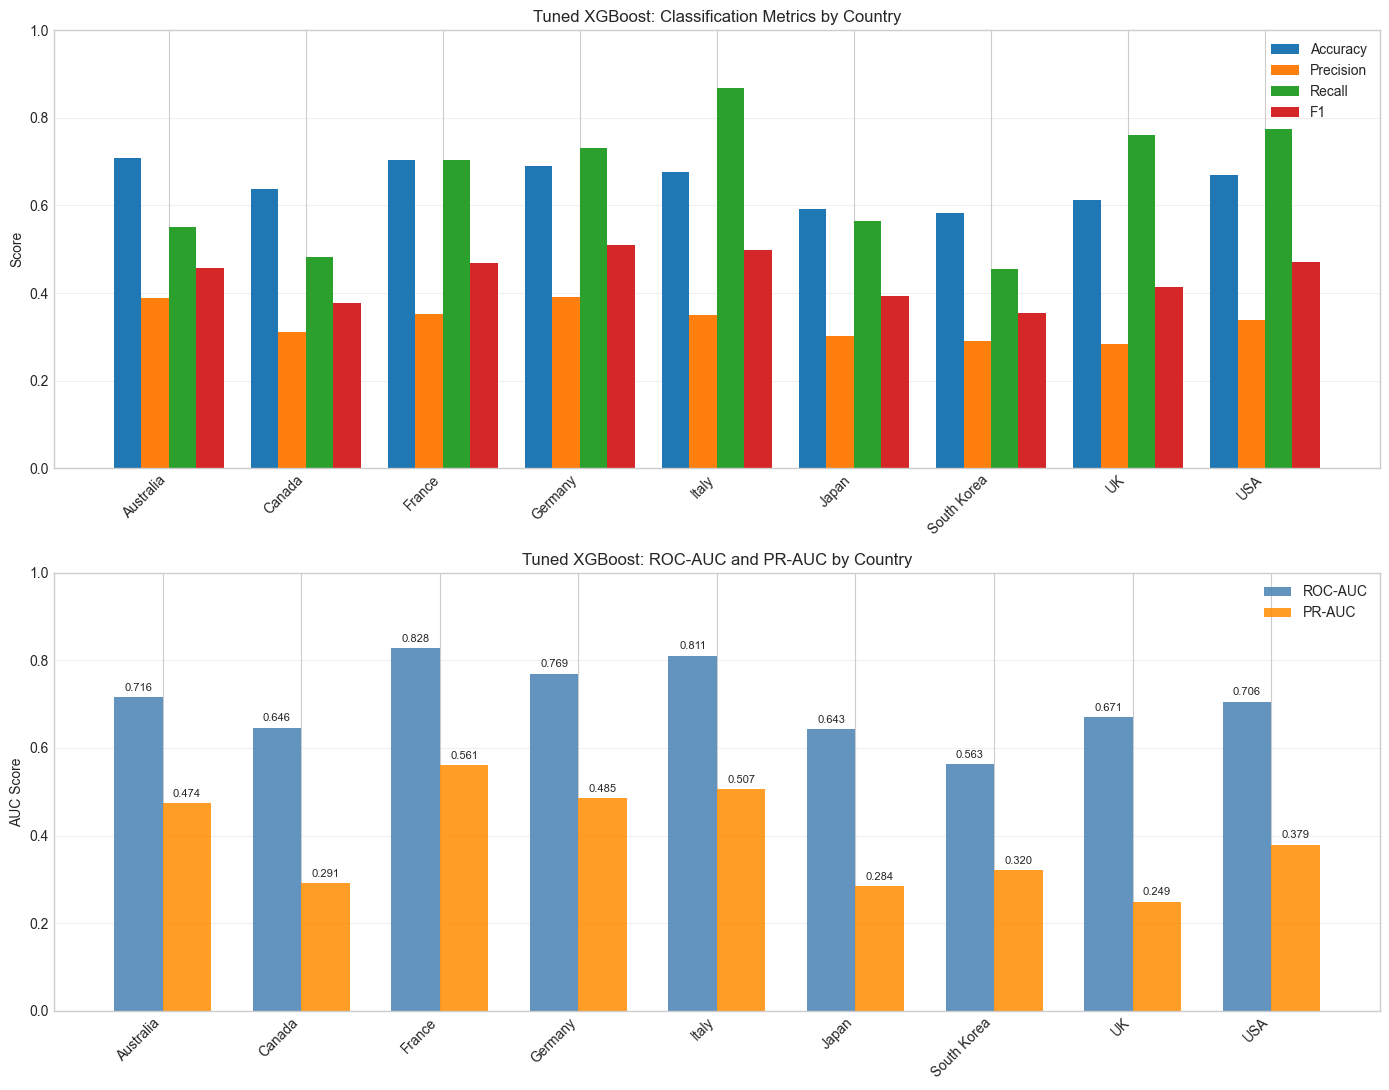

In [18]:
# Grouped bar chart: per-country metrics (including PR-AUC)
fig, axes = plt.subplots(2, 1, figsize=(14, 11))

# Classification metrics
plot_metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
x = np.arange(len(country_df))
width = 0.2

for i, metric in enumerate(plot_metrics):
    axes[0].bar(x + i * width, country_df[metric], width, label=metric)

axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(country_df.index, rotation=45, ha='right')
axes[0].set_ylabel('Score')
axes[0].set_title('Tuned XGBoost: Classification Metrics by Country')
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# ROC-AUC and PR-AUC side by side
width_auc = 0.35
axes[1].bar(x - width_auc / 2, country_df['ROC-AUC'], width_auc,
            label='ROC-AUC', color='steelblue', alpha=0.85)
axes[1].bar(x + width_auc / 2, country_df['PR-AUC'], width_auc,
            label='PR-AUC', color='darkorange', alpha=0.85)

# Add value labels on bars
for i, (roc_v, pr_v) in enumerate(zip(country_df['ROC-AUC'], country_df['PR-AUC'])):
    if not np.isnan(roc_v):
        axes[1].text(i - width_auc / 2, roc_v + 0.01, f'{roc_v:.3f}',
                     ha='center', va='bottom', fontsize=8)
    if not np.isnan(pr_v):
        axes[1].text(i + width_auc / 2, pr_v + 0.01, f'{pr_v:.3f}',
                     ha='center', va='bottom', fontsize=8)

axes[1].set_xticks(x)
axes[1].set_xticklabels(country_df.index, rotation=45, ha='right')
axes[1].set_ylabel('AUC Score')
axes[1].set_title('Tuned XGBoost: ROC-AUC and PR-AUC by Country')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 6. ROC and Precision-Recall Curves

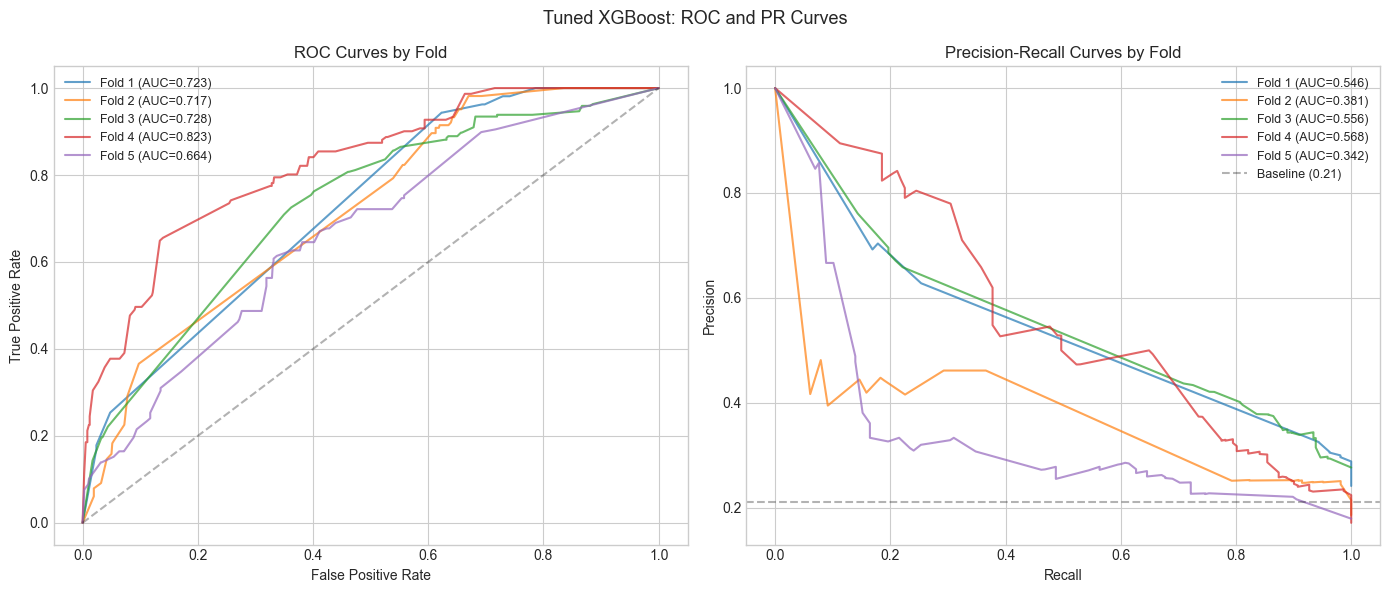

In [19]:
plot_roc_pr_curves(tuned_pred_df, N_SPLITS, 'XGBoost')

### Confusion Matrices

Side-by-side comparison of classification outcomes at the default (0.50) and
optimal thresholds. A lower threshold increases true positives (recession catches)
at the cost of more false positives (false alarms).

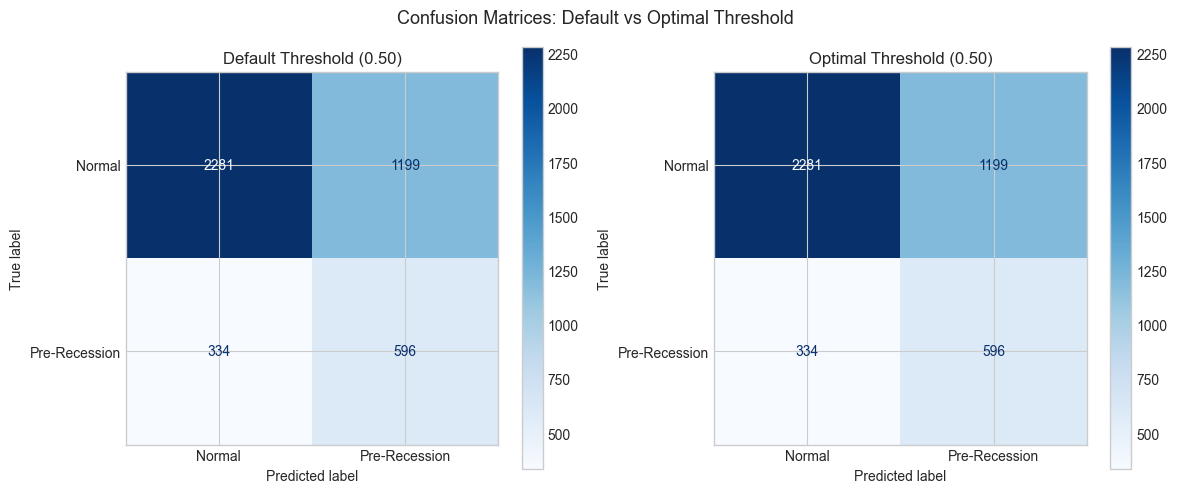

In [20]:
plot_confusion_matrices(tuned_pred_df, best_threshold)

## 7. Feature Importance

Train a model on each CV fold and extract `feature_importances_` (gain-based).
Averaging across folds produces more stable importance estimates than a single model.

In [21]:
# Average feature importance across CV folds for reliable estimates
tscv = TimeSeriesSplit(n_splits=N_SPLITS)
fold_importances = np.zeros((N_SPLITS, len(selected_features)))

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train_full, y_train_full = X.iloc[train_idx], y.iloc[train_idx]

    val_size = int(len(X_train_full) * VAL_FRAC)
    X_train = X_train_full.iloc[:-val_size]
    y_train = y_train_full.iloc[:-val_size]
    X_val = X_train_full.iloc[-val_size:]
    y_val = y_train_full.iloc[-val_size:]

    spw = (y_train == 0).sum() / (y_train == 1).sum()

    model = xgb.XGBClassifier(
        **best_params,
        n_estimators=MAX_ROUNDS,
        scale_pos_weight=spw,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
        eval_metric='aucpr',
        early_stopping_rounds=EARLY_STOP,
    )
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    fold_importances[fold] = model.feature_importances_

# Average across folds
mean_importances = fold_importances.mean(axis=0)
std_importances = fold_importances.std(axis=0)

importances = pd.DataFrame({
    'feature': selected_features,
    'importance': mean_importances,
    'std': std_importances
}).sort_values('importance', ascending=False)

### Feature Importance Visualization

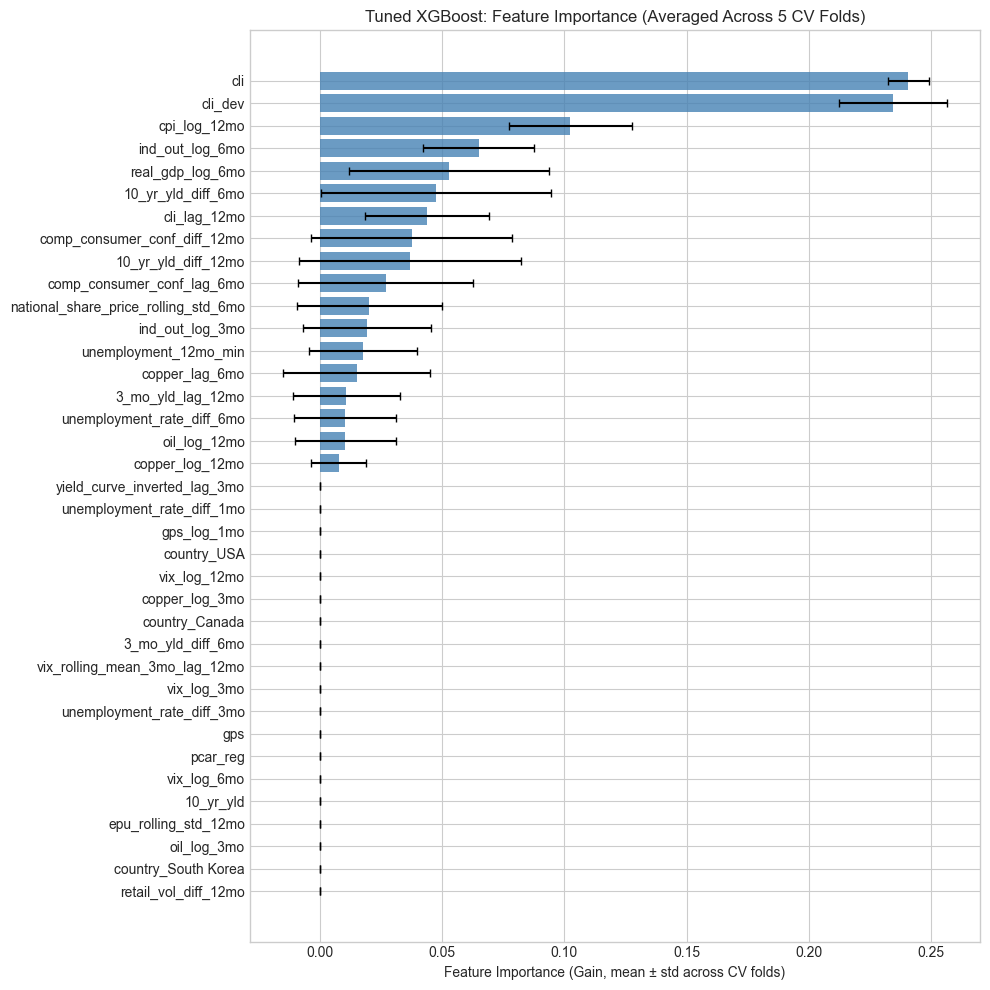

Feature Importance Ranking (mean ± std across folds):
   1. cli                                                 0.2406 ± 0.0085
   2. cli_dev                                             0.2344 ± 0.0219
   3. cpi_log_12mo                                        0.1025 ± 0.0253
   4. ind_out_log_6mo                                     0.0650 ± 0.0226
   5. real_gdp_log_6mo                                    0.0527 ± 0.0408
   6. 10_yr_yld_diff_6mo                                  0.0476 ± 0.0471
   7. cli_lag_12mo                                        0.0437 ± 0.0253
   8. comp_consumer_conf_diff_12mo                        0.0377 ± 0.0411
   9. 10_yr_yld_diff_12mo                                 0.0369 ± 0.0454
  10. comp_consumer_conf_lag_6mo                          0.0270 ± 0.0358
  11. national_share_price_rolling_std_6mo                0.0202 ± 0.0297
  12. ind_out_log_3mo                                     0.0193 ± 0.0260
  13. unemployment_12mo_min                               

In [22]:
# Plot all features
fig, ax = plt.subplots(figsize=(10, 10))
plot_data = importances.sort_values('importance', ascending=True)
ax.barh(plot_data['feature'], plot_data['importance'], xerr=plot_data['std'],
        color='steelblue', alpha=0.8, capsize=3)
ax.set_xlabel('Feature Importance (Gain, mean ± std across CV folds)')
ax.set_title('Tuned XGBoost: Feature Importance (Averaged Across 5 CV Folds)')
plt.tight_layout()
plt.show()

print('Feature Importance Ranking (mean ± std across folds):')
for i, (_, row) in enumerate(importances.iterrows(), 1):
    print(f'  {i:2d}. {row["feature"]:50s}  {row["importance"]:.4f} ± {row["std"]:.4f}')

## 8. Baseline vs Tuned Comparison

Side-by-side comparison of the baseline (default hyperparameters, 0.5 threshold)
vs the tuned model (optimized hyperparameters + optimal threshold).

In [23]:
comparison = build_model_comparison(
    baseline_df, baseline_pred_df,
    tuned_df, tuned_pred_df,
    final_df, best_threshold,
    naive_all_pos_f1, mean_prevalence,
    model_name='XGBoost',
)

XGBoost Model Comparison
                               ROC-AUC  PR-AUC    F1  Accuracy  Precision  Recall
Model                                                                            
Naive: Predict All Negative      0.500   0.211 0.000     0.789      0.000   0.000
Naive: Predict All Positive      0.500   0.211 0.346     0.211      0.211   1.000
Baseline (default HP, t=0.50)    0.699   0.405 0.346     0.752      0.396   0.338
Tuned HP (t=0.50)                0.731   0.478 0.428     0.652      0.332   0.641
Tuned HP + Threshold (t=0.50)    0.731   0.478 0.428     0.652      0.332   0.641

Improvement (Tuned HP + Threshold vs Baseline):
  ROC-AUC     : +0.032
  PR-AUC      : +0.073
  F1          : +0.082
  Precision   : -0.064
  Recall      : +0.303

Beats naive baselines?
  F1 (0.428) > predict-all-positive (0.346): True
  ROC-AUC (0.731) > random (0.500): True
  PR-AUC (0.478) > prevalence (0.211): True


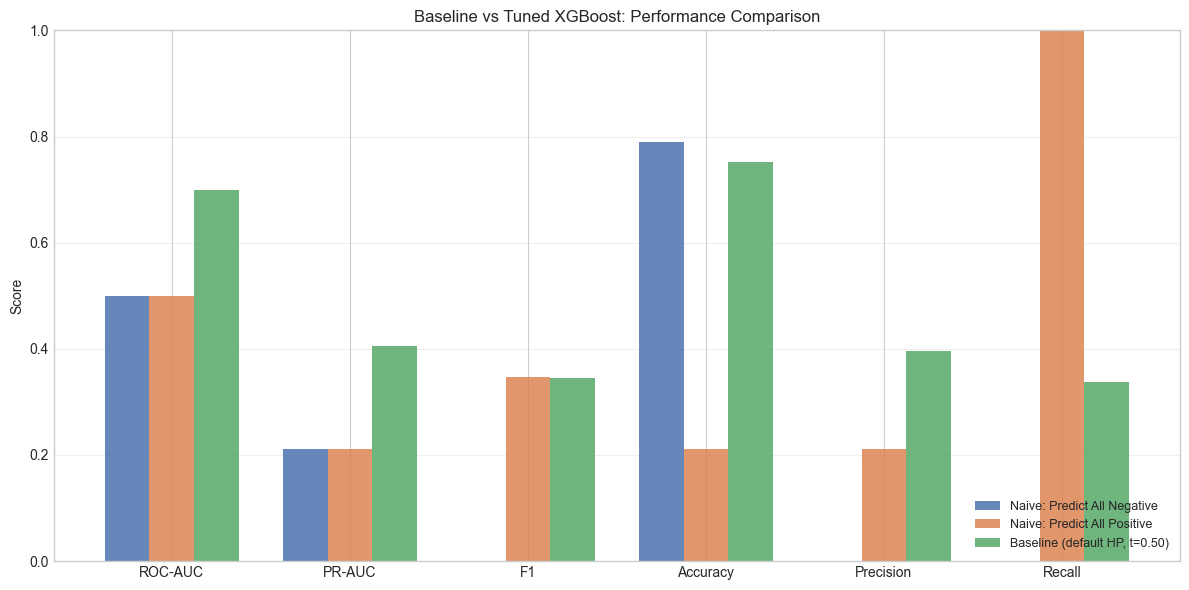

In [24]:
# Visual comparison
fig, ax = plt.subplots(figsize=(12, 6))

metrics_to_compare = ['ROC-AUC', 'PR-AUC', 'F1', 'Accuracy', 'Precision', 'Recall']
x = np.arange(len(metrics_to_compare))
width = 0.25

labels = comparison.index.tolist()
colors = ['#4C72B0', '#DD8452', '#55A868']

for i, (label, color) in enumerate(zip(labels, colors)):
    vals = [comparison.loc[label, m] for m in metrics_to_compare]
    ax.bar(x + i * width, vals, width, label=label, color=color, alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_to_compare)
ax.set_ylabel('Score')
ax.set_title('Baseline vs Tuned XGBoost: Performance Comparison')
ax.set_ylim(0, 1)
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Export Final Model Configuration

In [25]:
export_model_config(best_params, best_threshold, selected_features, final_df,
                    '../data/xgboost_model_config.pkl',
                    max_rounds=MAX_ROUNDS, early_stop=EARLY_STOP)

Exported to: data/xgboost_model_config.pkl

Model Configuration:
  Features:    37
  Threshold:   0.50
  Random state: 42
  Early stopping: 30 rounds (max 1000)

  Hyperparameters:
    colsample_bytree: 0.9060
    gamma: 1.8239
    grow_policy: depthwise
    learning_rate: 0.0047
    max_bin: 463
    max_delta_step: 3
    max_depth: 2
    min_child_weight: 1
    reg_alpha: 0.6526
    reg_lambda: 0.1197
    subsample: 0.8257
    tree_method: hist

  CV Performance:
    ROC-AUC: 0.731 ± 0.057
    PR-AUC:  0.478 ± 0.108
    F1:      0.428 ± 0.073


## Summary

| Stage | Description |
|-------|-------------|
| Baseline reproduction | XGBoost with default HP on selected features |
| Hyperparameter tuning (Optuna) | 250 trials with TPE Bayesian optimization, 12 hyperparameters + early stopping + MedianPruner |
| Threshold tuning | Sweep 0.05-0.95, select threshold maximizing mean F1 across folds |
| Final evaluation | Best HP + optimal threshold, per-fold and per-country metrics |

**Optuna (TPE):** Bayesian optimization via Tree-structured Parzen Estimators — models promising regions of the search space and focuses sampling there. `MedianPruner` kills unpromising trials early by comparing intermediate per-fold results against completed trials.

**Search space (12 hyperparameters):**
- Tree structure: `max_depth`, `max_bin`, `min_child_weight`, `gamma`, `max_delta_step`
- Tree growth: `grow_policy` (`depthwise` vs `lossguide`), `max_leaves` (conditional)
- Sampling: `subsample`, `colsample_bytree`
- Regularization: `learning_rate`, `reg_alpha`, `reg_lambda`

**Key design choices:**
- Per-fold `scale_pos_weight` (consistent with baseline, not a single global value)
- Early stopping in both tuning and evaluation (`n_estimators` up to 1000, stops after 30 rounds without improvement)
- PR-AUC as primary scoring metric (more informative than ROC-AUC for imbalanced data)
- `tree_method='hist'` required for `grow_policy` and `max_bin` support

**Consistency with prior notebooks:**
- `random_state=42` for all models and searches
- `TimeSeriesSplit(n_splits=5)` for all cross-validation
- Data cutoff at 2019-01-01 (pre-COVID contamination excluded)
- `scale_pos_weight` recomputed per training fold
- Same leaky columns excluded (`oecd_rec`, `technical_rec`, `pre_recession`)

**Exported:** `data/xgboost_model_config.pkl` containing best hyperparameters, threshold, and CV metrics.

## 10. XGBoost on Complete Data (NaN-Free)

Re-run the full pipeline on the complete preprocessed dataset (filtered to exclude
rows with any NaN). This provides:

1. A fair comparison baseline for models that cannot handle NaN (Logistic Regression, LSTM)
2. Analysis of how much information is lost by dropping early incomplete rows

The same hyperparameters, random state, CV strategy, and threshold tuning are applied.

In [26]:
# ── Load Complete Data ────────────────────────────────────────────────────────
df_c = pd.read_pickle('../data/milestone_ii_preprocessed_complete.pkl')

with open('../data/selected_features_complete.pkl', 'rb') as f:
    selected_features_c = pickle.load(f)

df_flat_c = df_c.reset_index()
df_flat_c = df_flat_c[df_flat_c['date'] < '2019-01-01']

X_c = df_flat_c[selected_features_c].copy()
y_c = df_flat_c['pre_recession']

inf_count_c = np.isinf(X_c).sum().sum()
X_c = X_c.replace([np.inf, -np.inf], np.nan)

nan_after = X_c.isnull().sum().sum()
scale_pos_weight_global_c = (y_c == 0).sum() / (y_c == 1).sum()

print(f'Complete dataset shape: {df_c.shape}')
print(f'After pre-2019 cutoff: {len(X_c)} observations (original: {len(X)})')
print(f'Replaced {inf_count_c} infinite values with NaN')
print(f'Remaining NaN: {nan_after}')
print(f'Positive class: {y_c.sum()} ({y_c.mean():.1%})')
print(f'Global scale_pos_weight: {scale_pos_weight_global_c:.2f}')
print(f'Date range: {df_flat_c["date"].min()} to {df_flat_c["date"].max()}')

Complete dataset shape: (2070, 237)
After pre-2019 cutoff: 1854 observations (original: 5292)
Replaced 0 infinite values with NaN
Remaining NaN: 0
Positive class: 336 (18.1%)
Global scale_pos_weight: 4.52
Date range: 2001-11-01 00:00:00 to 2018-12-01 00:00:00


### Baseline on Complete Data

Run the same default-HP XGBoost on the NaN-free subset to establish a comparison
baseline for LSTM and Logistic Regression (which cannot handle missing values).

In [27]:
baseline_df_c, baseline_pred_df_c = run_baseline_cv(X_c, y_c, df_flat_c)

Fold 1: Train to 2004-09, Test 2004-09-2007-07 | ROC-AUC: 0.634 | PR-AUC: 0.360 | F1: 0.189
Fold 2: Train to 2007-07, Test 2007-07-2010-05 | ROC-AUC: 0.632 | PR-AUC: 0.388 | F1: 0.338
Fold 3: Train to 2010-05, Test 2010-06-2013-04 | ROC-AUC: 0.612 | PR-AUC: 0.516 | F1: 0.240
Fold 4: Train to 2013-04, Test 2013-04-2016-02 | ROC-AUC: 0.728 | PR-AUC: 0.281 | F1: 0.203
Fold 5: Train to 2016-02, Test 2016-02-2018-12 | ROC-AUC: 0.699 | PR-AUC: 0.283 | F1: 0.136

Baseline (21 selected features, default hyperparameters):
  Mean ROC-AUC: 0.661 ± 0.050
  Mean PR-AUC:  0.366 ± 0.096
  Mean F1:      0.221 ± 0.075


### Hyperparameter Tuning on Complete Data

Independent Optuna search on the complete dataset — the optimal hyperparameters
may differ due to the smaller sample size (fewer observations, different time range).

In [28]:
best_params_c, study_c = run_optuna_tuning(X_c, y_c, study_name='xgboost_recession_complete')

Optuna: Running 250 trials with TPE sampler...


  0%|          | 0/250 [00:00<?, ?it/s]


Optuna search complete (250 trials, 87 pruned)
Best PR-AUC: 0.5456 ± 0.0960
Best ROC-AUC: 0.6817
Mean n_estimators (from early stopping): 56

Best hyperparameters:
  colsample_bytree: 0.7720
  gamma: 2.0990
  grow_policy: lossguide
  learning_rate: 0.0193
  max_bin: 238
  max_delta_step: 10
  max_depth: 13
  max_leaves: 64
  min_child_weight: 13
  reg_alpha: 5.6402
  reg_lambda: 0.0277
  subsample: 0.7287
  tree_method: hist


### Evaluation on Complete Data

Re-run CV with the best hyperparameters found by Optuna on the complete dataset.

In [29]:
tuned_df_c, tuned_pred_df_c, val_pred_df_c = evaluate_tuned_model(X_c, y_c, df_flat_c, best_params_c)

Fold 1: Train to 2004-09, Test 2004-09-2007-07 | ROC-AUC: 0.512 | PR-AUC: 0.609 | F1: 0.000
Fold 2: Train to 2007-07, Test 2007-07-2010-05 | ROC-AUC: 0.796 | PR-AUC: 0.614 | F1: 0.000
Fold 3: Train to 2010-05, Test 2010-06-2013-04 | ROC-AUC: 0.500 | PR-AUC: 0.642 | F1: 0.000
Fold 4: Train to 2013-04, Test 2013-04-2016-02 | ROC-AUC: 0.854 | PR-AUC: 0.461 | F1: 0.473
Fold 5: Train to 2016-02, Test 2016-02-2018-12 | ROC-AUC: 0.746 | PR-AUC: 0.401 | F1: 0.218

Tuned hyperparameters (default threshold=0.5):
  Mean ROC-AUC: 0.682 ± 0.165
  Mean PR-AUC:  0.546 ± 0.107
  Mean F1:      0.138 ± 0.210


### Threshold Tuning on Complete Data

Optimal threshold (from validation data): 0.33
  Mean validation F1 at optimal threshold: 0.340

  Test F1 at optimal threshold:        0.354
  Test Precision at optimal threshold:  0.260
  Test Recall at optimal threshold:     0.862
  Test F1 at default threshold (0.50):  0.138

Naive baselines (must beat these):
  Predict-all-positive F1: 0.329
  Predict-all-negative F1: 0.000
  Random classifier ROC-AUC: 0.500
  Random classifier PR-AUC:  0.199 (= class prevalence)


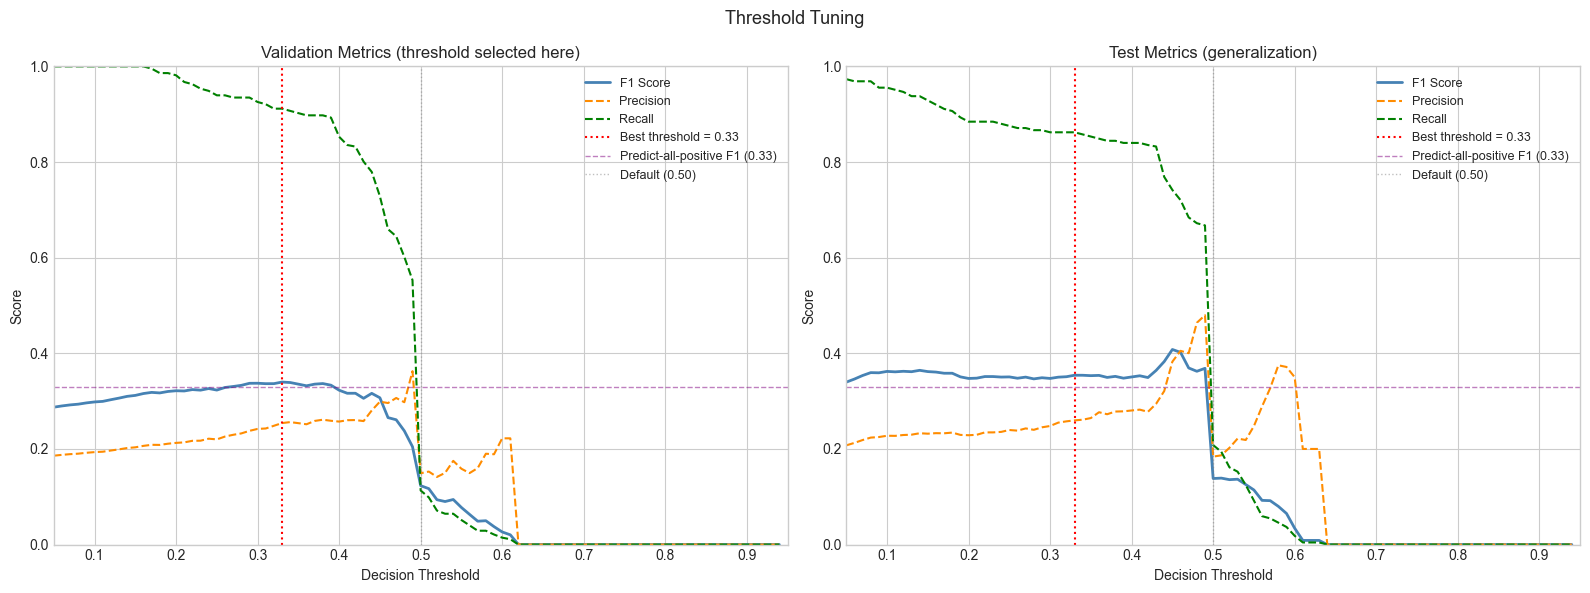

In [30]:
best_threshold_c, naive_all_pos_f1_c, mean_prevalence_c = tune_threshold(
    val_pred_df_c, tuned_pred_df_c, plot=True
)

### Performance Metrics on Complete Data

Per-fold and per-country metrics for the tuned model on the complete dataset.

In [31]:
final_df_c = compute_fold_metrics(tuned_pred_df_c, N_SPLITS, best_threshold_c)
country_df_c = compute_country_metrics(tuned_pred_df_c)

Per-Fold Metrics (tuned HP + optimal threshold)
 fold  accuracy  precision  recall    f1  roc_auc  pr_auc
    1     0.214      0.214   1.000 0.352    0.512   0.609
    2     0.214      0.214   1.000 0.352    0.796   0.614
    3     0.285      0.285   1.000 0.443    0.500   0.642
    4     0.207      0.149   1.000 0.260    0.854   0.461
    5     0.841      0.438   0.311 0.364    0.746   0.401

Mean ± Std:
  accuracy    : 0.352 ± 0.275
  precision   : 0.260 ± 0.110
  recall      : 0.862 ± 0.308
  f1          : 0.354 ± 0.065
  roc_auc     : 0.682 ± 0.165
  pr_auc      : 0.546 ± 0.107
Per-Country Classification Metrics (Tuned Model, Aggregated Across All CV Folds)
             Accuracy  Precision  Recall    F1  ROC-AUC  PR-AUC  Support (pos)  Total
Country                                                                              
Australia       0.398      0.255   0.972 0.405    0.732   0.271             36    171
Canada          0.398      0.267   0.900 0.411    0.776   0.581         

### Original vs Complete Data Comparison

Compare the tuned XGBoost on both datasets to quantify the impact of dropping
early incomplete rows. The original dataset has ~3x more observations but includes
NaN values; the complete dataset is NaN-free but covers a shorter time range.

In [32]:
# ── Original vs Complete Data Comparison ──────────────────────────────────────
comparison_data = pd.DataFrame([
    {
        'Dataset': 'Naive: Predict All Positive',
        'Observations': '-',
        'Threshold': '-',
        'ROC-AUC': 0.5,
        'PR-AUC': mean_prevalence,
        'F1': naive_all_pos_f1,
        'Precision': tuned_pred_df['y_true'].mean(),
        'Recall': 1.0,
    },
    {
        'Dataset': 'Original (with NaN)',
        'Observations': len(X),
        'Threshold': best_threshold,
        'ROC-AUC': final_df['roc_auc'].mean(),
        'PR-AUC': final_df['pr_auc'].mean(),
        'F1': final_df['f1'].mean(),
        'Precision': precision_score(tuned_pred_df['y_true'], tuned_pred_df['y_pred_opt'], zero_division=0),
        'Recall': recall_score(tuned_pred_df['y_true'], tuned_pred_df['y_pred_opt'], zero_division=0),
    },
    {
        'Dataset': 'Complete (NaN-free)',
        'Observations': len(X_c),
        'Threshold': best_threshold_c,
        'ROC-AUC': final_df_c['roc_auc'].mean(),
        'PR-AUC': final_df_c['pr_auc'].mean(),
        'F1': final_df_c['f1'].mean(),
        'Precision': precision_score(tuned_pred_df_c['y_true'], tuned_pred_df_c['y_pred_opt'], zero_division=0),
        'Recall': recall_score(tuned_pred_df_c['y_true'], tuned_pred_df_c['y_pred_opt'], zero_division=0),
    }
]).set_index('Dataset')

print('XGBoost: Original vs Complete Data Comparison')
print('=' * 95)
print(comparison_data.to_string(float_format='{:.3f}'.format))

# Deltas
print(f'\nDelta (Complete - Original):')
for col in ['ROC-AUC', 'PR-AUC', 'F1', 'Precision', 'Recall']:
    delta = comparison_data.loc['Complete (NaN-free)', col] - comparison_data.loc['Original (with NaN)', col]
    print(f'  {col:12s}: {delta:+.3f}')

# Beats naive baselines?
print(f'\nBeats naive baselines?')
for dataset_name, df_metrics, prev in [
    ('Original', final_df, mean_prevalence),
    ('Complete', final_df_c, mean_prevalence_c),
]:
    f1_val = df_metrics['f1'].mean()
    roc_val = df_metrics['roc_auc'].mean()
    pr_val = df_metrics['pr_auc'].mean()
    naive_f1_val = naive_all_pos_f1 if dataset_name == 'Original' else naive_all_pos_f1_c
    print(f'  {dataset_name}: F1={f1_val:.3f} > all-pos={naive_f1_val:.3f} ({f1_val > naive_f1_val}), '
          f'ROC-AUC={roc_val:.3f} > 0.5 ({roc_val > 0.5}), '
          f'PR-AUC={pr_val:.3f} > prev={prev:.3f} ({pr_val > prev})')

XGBoost: Original vs Complete Data Comparison
                            Observations Threshold  ROC-AUC  PR-AUC    F1  Precision  Recall
Dataset                                                                                     
Naive: Predict All Positive            -         -    0.500   0.211 0.346      0.211   1.000
Original (with NaN)                 5292     0.500    0.731   0.478 0.428      0.332   0.641
Complete (NaN-free)                 1854     0.330    0.682   0.546 0.354      0.222   0.899

Delta (Complete - Original):
  ROC-AUC     : -0.049
  PR-AUC      : +0.067
  F1          : -0.074
  Precision   : -0.110
  Recall      : +0.258

Beats naive baselines?
  Original: F1=0.428 > all-pos=0.346 (True), ROC-AUC=0.731 > 0.5 (True), PR-AUC=0.478 > prev=0.211 (True)
  Complete: F1=0.354 > all-pos=0.329 (True), ROC-AUC=0.682 > 0.5 (True), PR-AUC=0.546 > prev=0.199 (True)


### Export Complete Data Configuration

In [33]:
export_model_config(best_params_c, best_threshold_c, selected_features_c, final_df_c,
                    '../data/xgboost_complete_model_config.pkl',
                    max_rounds=MAX_ROUNDS, early_stop=EARLY_STOP, dataset='complete')

Exported to: data/xgboost_complete_model_config.pkl

Model Configuration:
  Features:    21
  Threshold:   0.33
  Random state: 42
  Early stopping: 30 rounds (max 1000)

  Hyperparameters:
    colsample_bytree: 0.7720
    gamma: 2.0990
    grow_policy: lossguide
    learning_rate: 0.0193
    max_bin: 238
    max_delta_step: 10
    max_depth: 13
    max_leaves: 64
    min_child_weight: 13
    reg_alpha: 5.6402
    reg_lambda: 0.0277
    subsample: 0.7287
    tree_method: hist

  CV Performance:
    ROC-AUC: 0.682 ± 0.165
    PR-AUC:  0.546 ± 0.107
    F1:      0.354 ± 0.065
